# 03. Feature Engineering and Structural Balance

Export node, pair, structural-balance, text-property, and merged modeling tables.

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

from src.phase2 import export_phase2_tables, load_phase1_filtered

phase1_path = root / 'data' / 'processed' / 'phase1_kcore_filtered.csv'
phase2_dir = root / 'data' / 'processed' / 'phase2'
phase2_dir.mkdir(parents=True, exist_ok=True)
phase1_path

WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/processed/phase1_kcore_filtered.csv')

In [2]:
frame = load_phase1_filtered(phase1_path)
paths = export_phase2_tables(frame, phase2_dir)
{key: str(value) for key, value in paths.items()}

{'node_features': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase2\\phase2_node_features.csv',
 'edge_features': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase2\\phase2_edge_features.csv',
 'triadic_features': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase2\\phase2_triadic_features.csv',
 'text_features': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase2\\phase2_text_features.csv',
 'modeling_table': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_anal

## Direct Feature Diagnostics

Preview the generated feature tables and structural-balance distribution.

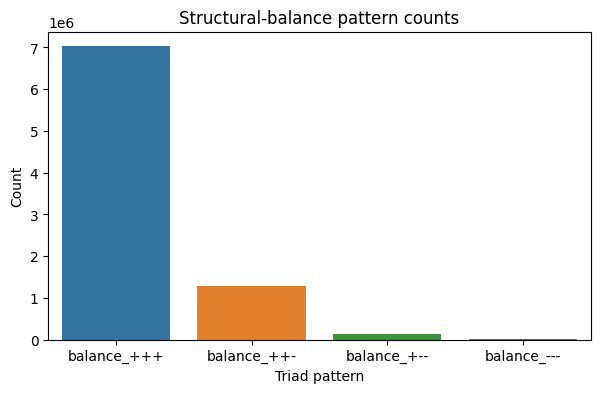

{'node_feature_rows': 12968,
 'detected_communities': 30,
 'community_or_clustering_columns': ['source_community_id',
  'source_community_size',
  'source_clustering_coefficient',
  'source_community_negative_ratio',
  'source_community_out_negative_ratio',
  'source_community_in_negative_ratio',
  'target_community_id',
  'target_community_size',
  'target_clustering_coefficient',
  'target_community_negative_ratio',
  'target_community_out_negative_ratio',
  'target_community_in_negative_ratio',
  'same_community',
  'community_size_ratio',
  'community_negative_ratio_gap'],
 'modeling_preview':   source_subreddit   target_subreddit  interaction_count  positive_count  \
 0    100daysofketo  bodyweightfitness                  1               1   
 1    100daysofketo      documentaries                  1               1   
 2    100daysofketo               keto                  5               5   
 3    100daysofketo             loseit                  1               1   
 4    100da

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

triadic = pd.read_csv(phase2_dir / 'phase2_triadic_features.csv')
modeling = pd.read_csv(phase2_dir / 'phase2_modeling_table.csv', nrows=5)
node_features = pd.read_csv(phase2_dir / 'phase2_node_features.csv')
full_modeling_columns = pd.read_csv(phase2_dir / 'phase2_modeling_table.csv', nrows=0).columns.tolist()

balance_cols = ['balance_+++', 'balance_++-', 'balance_+--', 'balance_---']
balance_totals = triadic[balance_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=balance_totals.index, y=balance_totals.values, hue=balance_totals.index, legend=False)
plt.title('Structural-balance pattern counts')
plt.xlabel('Triad pattern')
plt.ylabel('Count')
plt.show()

community_cols = [c for c in full_modeling_columns if 'community' in c or 'clustering' in c]
{
    'node_feature_rows': len(node_features),
    'detected_communities': int(node_features['community_id'].nunique()),
    'community_or_clustering_columns': community_cols,
    'modeling_preview': modeling,
}